In [41]:
import warnings
from glob import glob

import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [42]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Get place name
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    # Drop null values majority columns
    df.drop(columns=['floor','expenses'],inplace=True);

    #Drop low and high cardinality categorical features
    df.drop(columns=['operation','property_type','properati_url','currency'],inplace=True);

    #Drop Leaky Features
    df.drop(columns=[
         'price',
         'price_aprox_local_currency',
         'price_per_m2',
         'price_usd_per_m2',
    ],inplace=True)

    
    #Drop multicollinearity Features
    df.drop(columns=[
         'surface_total_in_m2',
         'rooms',
    ],inplace=True)
    
    return df

In [43]:
files = glob("data/buenos-aires-real-estate-*.csv")
files

['data/buenos-aires-real-estate-3.csv',
 'data/buenos-aires-real-estate-2.csv',
 'data/buenos-aires-real-estate-1.csv',
 'data/buenos-aires-real-estate-5.csv',
 'data/buenos-aires-real-estate-4.csv']

In [44]:
assert len(files) == 5, f"`files` should contain 5 items, not {len(files)}"

In [45]:
# list comprehension over [] and append 
frames = [ wrangle(file) for file in files]

In [46]:
# Check your work
assert len(frames) == 5, f"`frames` should contain 5 items, not {len(frames)}"
assert all(
    [isinstance(frame, pd.DataFrame) for frame in frames]
), "The items in `frames` should all be DataFrames."

In [47]:
df = pd.concat(frames,ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,120000.0,55.0,-34.616004,-58.470506,Villa General Mitre
1,89000.0,37.0,-34.584712,-58.444927,Palermo
2,183495.0,57.0,-34.554652,-58.493644,Saavedra
3,95000.0,47.0,-34.610581,-58.479625,Villa del Parque
4,95000.0,35.0,-34.558227,-58.458357,Belgrano


In [48]:
# Check your work
assert len(df) == 6582, f"`df` has the wrong number of rows: {len(df)}"
assert df.shape[1] <= 17, f"`df` has too many columns: {df.shape[1]}"

In [49]:
#how many nulls is too much? 50% or more
df.isnull().sum() / len(df)

price_aprox_usd          0.000000
surface_covered_in_m2    0.000000
lat                      0.040413
lon                      0.040413
neighborhood             0.000000
dtype: float64

We can let go of floor and expenses as the isnull are 71% and 73%

In [50]:
df.select_dtypes("object").head()

,neighborhood
0,Villa General Mitre
1,Palermo
2,Saavedra
3,Villa del Parque
4,Belgrano


In [51]:
df.select_dtypes("object").nunique()


neighborhood    57
dtype: int64

operation is always sell so no use, and properati_url has 6K+ which will lead to lot of features in one hot encoding and dimensionality curse so we can drop both low and high cardinality

In [52]:
sorted(df.columns)

['lat', 'lon', 'neighborhood', 'price_aprox_usd', 'surface_covered_in_m2']

Leaky features are ones that make target vector obvious like team points and winner , cancer_hospital name and cancer outcome

In [53]:
# Check your work
assert len(df) == 6582, f"`df` has the wrong number of rows: {len(df)}"
assert df.shape[1] <= 7, f"`df` has too many columns: {df.shape[1]}"

Finally, the last issue we need to keep an eye out for is **multicollinearity**, that is, features in our feature matrix that are highly correlated with each other. A good way to detect this is to use a heatmap. Let's make one!


In [54]:
df.select_dtypes("number").drop(columns=["price_aprox_usd"]).corr()


,surface_covered_in_m2,lat,lon
surface_covered_in_m2,1.000000,0.028538,0.034515
lat,0.028538,1.000000,-0.262439
lon,0.034515,-0.262439,1.000000


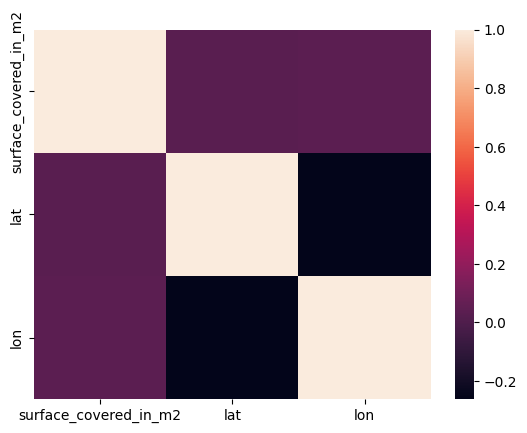

In [55]:
corr = df.select_dtypes("number").drop(columns=["price_aprox_usd"]).corr()
sns.heatmap(corr);

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB


we'll drop surface_total_in_m2, surface_covered_in_m2 and rooms -> surface_covered_in_m2 has highest non-null data so we drop others

After dropping of multicolline we see no orange in heatmap